# ***Proyecto Final Inteligencia Artificial l***
# ***Impacto de los Videojuegos en la Salud Mental***

---

### Grupo F1
### Integrantes:
- Dylan Jhoan Velandia Velandia - 2210072
- Juan Diego Manosalva Salamanca- 2220059

---

## **Introducción**
En los últimos años, los videojuegos se han convertido en una de las formas de entretenimiento más populares a nivel mundial, especialmente entre adolescentes y adultos jóvenes. Si bien el gaming puede ofrecer beneficios como el desarrollo de habilidades cognitivas, coordinación y socialización en entornos digitales, también ha surgido preocupación respecto a su posible impacto en la salud mental, el rendimiento académico o laboral, y los hábitos de vida de los jugadores.<br>
Para poder analizar la relación entre los hábitos de juego y diferentes indicadores de bienestar físico, emocional y social, se hará uso de un dataset que contiene información de aproximadamente 1000 individuos, incluyendo variables demográficas (como edad y género), patrones de juego (horas diarias de juego, género de videojuegos, plataforma utilizada y años de experiencia), así como indicadores de salud y estilo de vida, entre ellos calidad del sueño, estado de ánimo, rendimiento académico o laboral, síntomas de abstinencia, niveles de aislamiento social y actividad física.<br>
Los resultados de este análisis pueden contribuir a una mejor comprensión del impacto del gaming en la vida cotidiana, así como servir de apoyo para el desarrollo de estrategias de prevención, concienciación y uso responsable de los videojuegos


##Importación de Librerías necesarias y visualización del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Inteligencia Artificial l 2026-1/Proyecto Final/Gaming and Mental Health.csv')
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


---
##1. EXPLORACIÓN INICIAL
---

In [ ]:
print("=" * 60)
print("DATASET CARGADO EXITOSAMENTE")
print("=" * 60)
# ──   df.head() ────────────────────────────────────────────
print("\n PRIMERAS 5 FILAS DEL DATASET (.head())")
print("-" * 60)
print(df.head())

# ── df.columns ───────────────────────────────────────────
print("\n COLUMNAS DEL DATASET (.columns)")
print("-" * 60)
print(df.columns.tolist())

# ── df.info() ────────────────────────────────────────────
print("\n INFORMACIÓN GENERAL DEL DATASET (.info())")
print("-" * 60)
df.info()

# ── df.describe() ────────────────────────────────────────
print("\n ESTADÍSTICAS DESCRIPTIVAS (.describe())")
print("-" * 60)
print(df.describe(include='all'))

# ── .shape ─────────────────────────────────────────────
print("\n DIMENSIONES DEL DATASET (.shape)")
print("-" * 60)
print(f"   Filas   : {df.shape[0]}")
print(f"   Columnas: {df.shape[1]}")

# ── Valores nulos ──────────────────────────────────────
print("\n VALORES NULOS POR COLUMNA")
print("-" * 60)
print(df.isnull().sum()[df.isnull().sum() > 0])

DATASET CARGADO EXITOSAMENTE

 PRIMERAS 5 FILAS DEL DATASET (.head())
------------------------------------------------------------
  record_id  age  gender  daily_gaming_hours     game_genre    primary_game  \
0    GD0001   17    Male                11.1   Mobile Games  Clash of Clans   
1    GD0002   21    Male                 3.0           MOBA          Dota 2   
2    GD0003   23    Male                 7.6            FPS           CS:GO   
3    GD0004   20  Female                 7.2            RPG          Skyrim   
4    GD0005   18    Male                 6.8  Battle Royale    Apex Legends   

  gaming_platform  sleep_hours sleep_quality sleep_disruption_frequency  ...  \
0              PC          3.7     Very Poor                  Sometimes  ...   
1              PC          7.2          Fair                     Rarely  ...   
2  Multi-platform          4.4          Fair                      Often  ...   
3  Multi-platform          5.1          Fair                      Often  .

---
##2. Descripción de cada columna
---

In [ ]:
print("\n" + "=" * 60)
print(" DESCRIPCIÓN DE VARIABLES")
print("=" * 60)

descripciones = {
    "record_id"                      : "Identificador único del participante (ej. GD0001). No aporta valor predictivo.",
    "age"                            : "Edad del jugador en años. Variable numérica continua.",
    "gender"                         : "Género del participante (Male / Female / Other). Variable categórica.",
    "daily_gaming_hours"             : "Horas diarias dedicadas a videojuegos. Numérica continua — variable clave del estudio.",
    "game_genre"                     : "Género del videojuego principal (FPS, RPG, MOBA, etc.). Categórica.",
    "primary_game"                   : "Juego específico más jugado (CS:GO, Dota 2, etc.). Categórica de alta cardinalidad.",
    "gaming_platform"                : "Plataforma de juego (PC, Mobile, Console, Multi-platform). Categórica.",
    "sleep_hours"                    : "Horas de sueño por noche. Numérica continua — VARIABLE OBJETIVO principal.",
    "sleep_quality"                  : "Calidad subjetiva del sueño (Very Poor / Poor / Fair / Good / Excellent). Ordinal.",
    "sleep_disruption_frequency"     : "Frecuencia con que los videojuegos interrumpen el sueño (Never/Rarely/Sometimes/Often/Daily). Ordinal.",
    "academic_work_performance"      : "Rendimiento académico o laboral auto-reportado (Below Average/Average/Good/Excellent). Ordinal.",
    "grades_gpa"                     : "GPA del estudiante (0–4 aprox.). Numérica continua. Tiene valores nulos (~25%).",
    "work_productivity_score"        : "Puntuación de productividad laboral (escala 1–10). Numérica continua. Tiene valores nulos (~33%).",
    "mood_state"                     : "Estado de ánimo predominante (Anxious, Irritable, Withdrawn, etc.). Categórica.",
    "mood_swing_frequency"           : "Frecuencia de cambios de humor (Never/Rarely/Sometimes/Often/Daily). Ordinal.",
    "withdrawal_symptoms"            : "¿Experimenta síntomas de abstinencia al no jugar? (True/False). Booleana.",
    "loss_of_other_interests"        : "¿Ha perdido interés en otras actividades? (True/False). Booleana.",
    "continued_despite_problems"     : "¿Continúa jugando a pesar de problemas? (True/False). Indicador de adicción.",
    "eye_strain"                     : "¿Sufre fatiga visual por jugar? (True/False). Booleana.",
    "back_neck_pain"                 : "¿Sufre dolor de espalda/cuello? (True/False). Booleana.",
    "weight_change_kg"               : "Cambio de peso en kg (positivo = ganó, negativo = perdió). Numérica continua.",
    "exercise_hours_weekly"          : "Horas de ejercicio a la semana. Numérica continua.",
    "social_isolation_score"         : "Puntuación de aislamiento social (escala 1–10). Numérica discreta.",
    "face_to_face_social_hours_weekly": "Horas semanales de interacción social presencial. Numérica continua.",
    "monthly_game_spending_usd"      : "Gasto mensual en videojuegos en USD. Numérica continua.",
    "years_gaming"                   : "Años que lleva jugando videojuegos. Numérica discreta.",
    "gaming_addiction_risk_level"    : "Nivel de riesgo de adicción (Low/Moderate/High/Severe). VARIABLE OBJETIVO ordinal.",
}

for col, desc in descripciones.items():
    print(f"  • {col:<35} → {desc}")


 DESCRIPCIÓN DE VARIABLES
  • record_id                           → Identificador único del participante (ej. GD0001). No aporta valor predictivo.
  • age                                 → Edad del jugador en años. Variable numérica continua.
  • gender                              → Género del participante (Male / Female / Other). Variable categórica.
  • daily_gaming_hours                  → Horas diarias dedicadas a videojuegos. Numérica continua — variable clave del estudio.
  • game_genre                          → Género del videojuego principal (FPS, RPG, MOBA, etc.). Categórica.
  • primary_game                        → Juego específico más jugado (CS:GO, Dota 2, etc.). Categórica de alta cardinalidad.
  • gaming_platform                     → Plataforma de juego (PC, Mobile, Console, Multi-platform). Categórica.
  • sleep_hours                         → Horas de sueño por noche. Numérica continua — VARIABLE OBJETIVO principal.
  • sleep_quality                       → Calidad

 ---
## 3. SEPARACIÓN: COLUMNAS CATEGÓRICAS vs NUMÉRICAS
 ---

In [ ]:
print("\n" + "=" * 60)
print("  SEPARACIÓN DE COLUMNAS POR TIPO")
print("=" * 60)

# Booleanas — las tratamos aparte para mayor claridad
bool_cols = df.select_dtypes(include='bool').columns.tolist()

# Numéricas (sin record_id)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Categóricas (object/string, sin record_id ni booleanas ya separadas)
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ('record_id',)]

print(f"\n Columnas NUMÉRICAS ({len(num_cols)}):")
print("   ", num_cols)

print(f"\n Columnas CATEGÓRICAS ({len(cat_cols)}):")
print("   ", cat_cols)

print(f"\n  Columnas BOOLEANAS ({len(bool_cols)}):")
print("   ", bool_cols)

# Sub-dataframes
df_numericas   = df[num_cols]
df_categoricas = df[cat_cols]


  SEPARACIÓN DE COLUMNAS POR TIPO

 Columnas NUMÉRICAS (11):
    ['age', 'daily_gaming_hours', 'sleep_hours', 'grades_gpa', 'work_productivity_score', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming']

 Columnas CATEGÓRICAS (10):
    ['gender', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'mood_state', 'mood_swing_frequency', 'gaming_addiction_risk_level']

  Columnas BOOLEANAS (5):
    ['withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain']


---
## 4. ANÁLISIS IQR (DETECCIÓN DE OUTLIERS)
---


 ANÁLISIS IQR — DETECCIÓN DE OUTLIERS

Columna                                   Q1       Q3      IQR   Límite Inf   Límite Sup   Outliers
-----------------------------------------------------------------------------------------------
  age                                  18.00    22.00     4.00        12.00        28.00         50
  daily_gaming_hours                    4.10     8.03     3.93        -1.79        13.91          6
  sleep_hours                           4.80     6.60     1.80         2.10         9.30          0
  grades_gpa                            1.76     3.28     1.52        -0.52         5.56          0
  work_productivity_score               3.00     8.00     5.00        -4.50        15.50          0
  weight_change_kg                      0.40     2.10     1.70        -2.15         4.65         40
  exercise_hours_weekly                 5.70     8.20     2.50         1.95        11.95          2
  social_isolation_score                2.00     5.00     3.00  

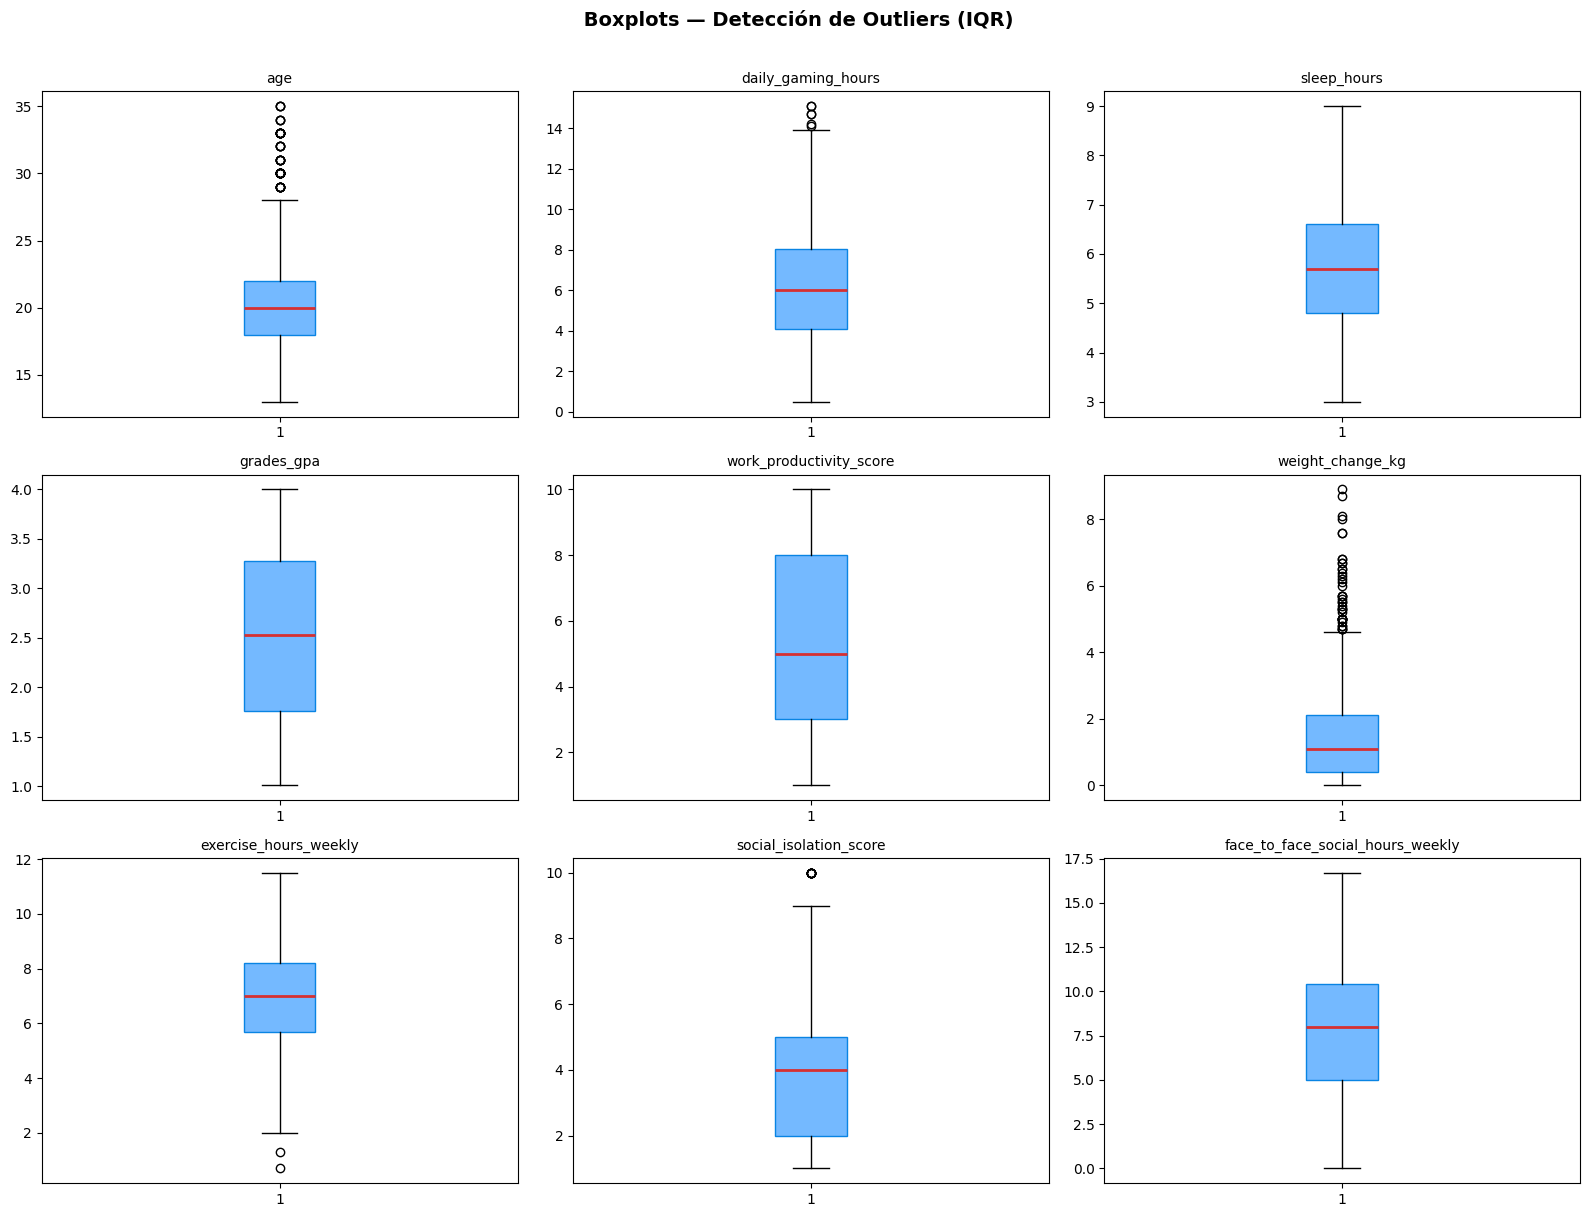

    Gráfico guardado: boxplots_iqr.png


In [ ]:
print("\n" + "=" * 60)
print(" ANÁLISIS IQR — DETECCIÓN DE OUTLIERS")
print("=" * 60)

print(f"\n{'Columna':<35} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Límite Inf':>12} {'Límite Sup':>12} {'Outliers':>10}")
print("-" * 95)

outlier_resumen = {}
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    li  = Q1 - 1.5 * IQR
    ls  = Q3 + 1.5 * IQR
    n_out = ((df[col] < li) | (df[col] > ls)).sum()
    outlier_resumen[col] = n_out
    print(f"  {col:<33} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {li:>12.2f} {ls:>12.2f} {n_out:>10}")

# Gráfico Boxplot para visualizar outliers
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols[:9]):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#74b9ff", color="#0984e3"),
                    medianprops=dict(color="#d63031", linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
plt.suptitle(" Boxplots — Detección de Outliers (IQR)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("boxplots_iqr.png", bbox_inches='tight')
plt.show()
print("    Gráfico guardado: boxplots_iqr.png")

---
## 5. PREPROCESAMIENTO PARA REGRESIÓN
---


In [ ]:
print("\n" + "=" * 60)
print("  PREPROCESAMIENTO — PREPARACIÓN PARA REGRESIÓN")
print("=" * 60)

df_model = df.drop(columns=['record_id', 'primary_game', 'gaming_addiction_risk_level'], errors='ignore').copy()

# ── 5.1 Imputación de valores nulos ─────────────────────────
df_model['grades_gpa'] = df_model['grades_gpa'].fillna(df_model['grades_gpa'].median())
df_model['work_productivity_score'] = df_model['work_productivity_score'].fillna(df_model['work_productivity_score'].median())
print("\n    Valores nulos imputados con la mediana.")

# ── 5.2 Codificación ordinal manual ─────────────────────────
ordinal_maps = {
    "sleep_quality"              : {"Very Poor": 1, "Poor": 2, "Fair": 3, "Good": 4, "Excellent": 5},
    "sleep_disruption_frequency" : {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Daily": 5},
    "academic_work_performance"  : {"Below Average": 1, "Average": 2, "Good": 3, "Excellent": 4},
    "mood_swing_frequency"       : {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Daily": 5},
}
for col, mapping in ordinal_maps.items():
    df_model[col] = df_model[col].map(mapping)

print("    Variables ordinales codificadas manualmente.")

# ── 5.3 Label Encoding para nominales ───────────────────────
nominal_cats = ['gender', 'game_genre', 'gaming_platform', 'mood_state']
le = LabelEncoder()
for col in nominal_cats:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("    Variables nominales codificadas con LabelEncoder.")

# ── 5.4 Booleanas → enteros ─────────────────────────────────
for col in bool_cols:
    df_model[col] = df_model[col].astype(int)

print("    Variables booleanas convertidas a 0/1.")
print(f"\n   Dataset listo: {df_model.shape[0]} filas × {df_model.shape[1]} columnas")


  PREPROCESAMIENTO — PREPARACIÓN PARA REGRESIÓN

    Valores nulos imputados con la mediana.
    Variables ordinales codificadas manualmente.
    Variables nominales codificadas con LabelEncoder.
    Variables booleanas convertidas a 0/1.

   Dataset listo: 1000 filas × 24 columnas


---
## 6. REGRESIÓN LINEAL — Variable objetivo: sleep_hours
---


 MODELO DE REGRESIÓN — OBJETIVO: sleep_hours

── Comparativa de Modelos ──────────────────────────────

  🔹 Regresión Lineal Múltiple
     RMSE : 0.8815
     MAE  : 0.7062
     R²   : 0.6311

  🔹 Ridge
     RMSE : 0.8810
     MAE  : 0.7057
     R²   : 0.6315

  🔹 Lasso
     RMSE : 0.9084
     MAE  : 0.7408
     R²   : 0.6083

── Top 10 variables más influyentes (por |coef| LR) ───
                         Feature   Coef_LR  Coef_Ridge  Coef_Lasso
              daily_gaming_hours -0.917558   -0.905303   -0.775779
       monthly_game_spending_usd  0.289786    0.287595    0.000000
             withdrawal_symptoms -0.185793   -0.185793   -0.109671
                   sleep_quality  0.179020    0.179410    0.140517
                      game_genre -0.095988   -0.095991   -0.000000
face_to_face_social_hours_weekly  0.094118    0.097565    0.022907
       academic_work_performance  0.084198    0.084323    0.025725
                      eye_strain -0.064830   -0.065442   -0.030447
            

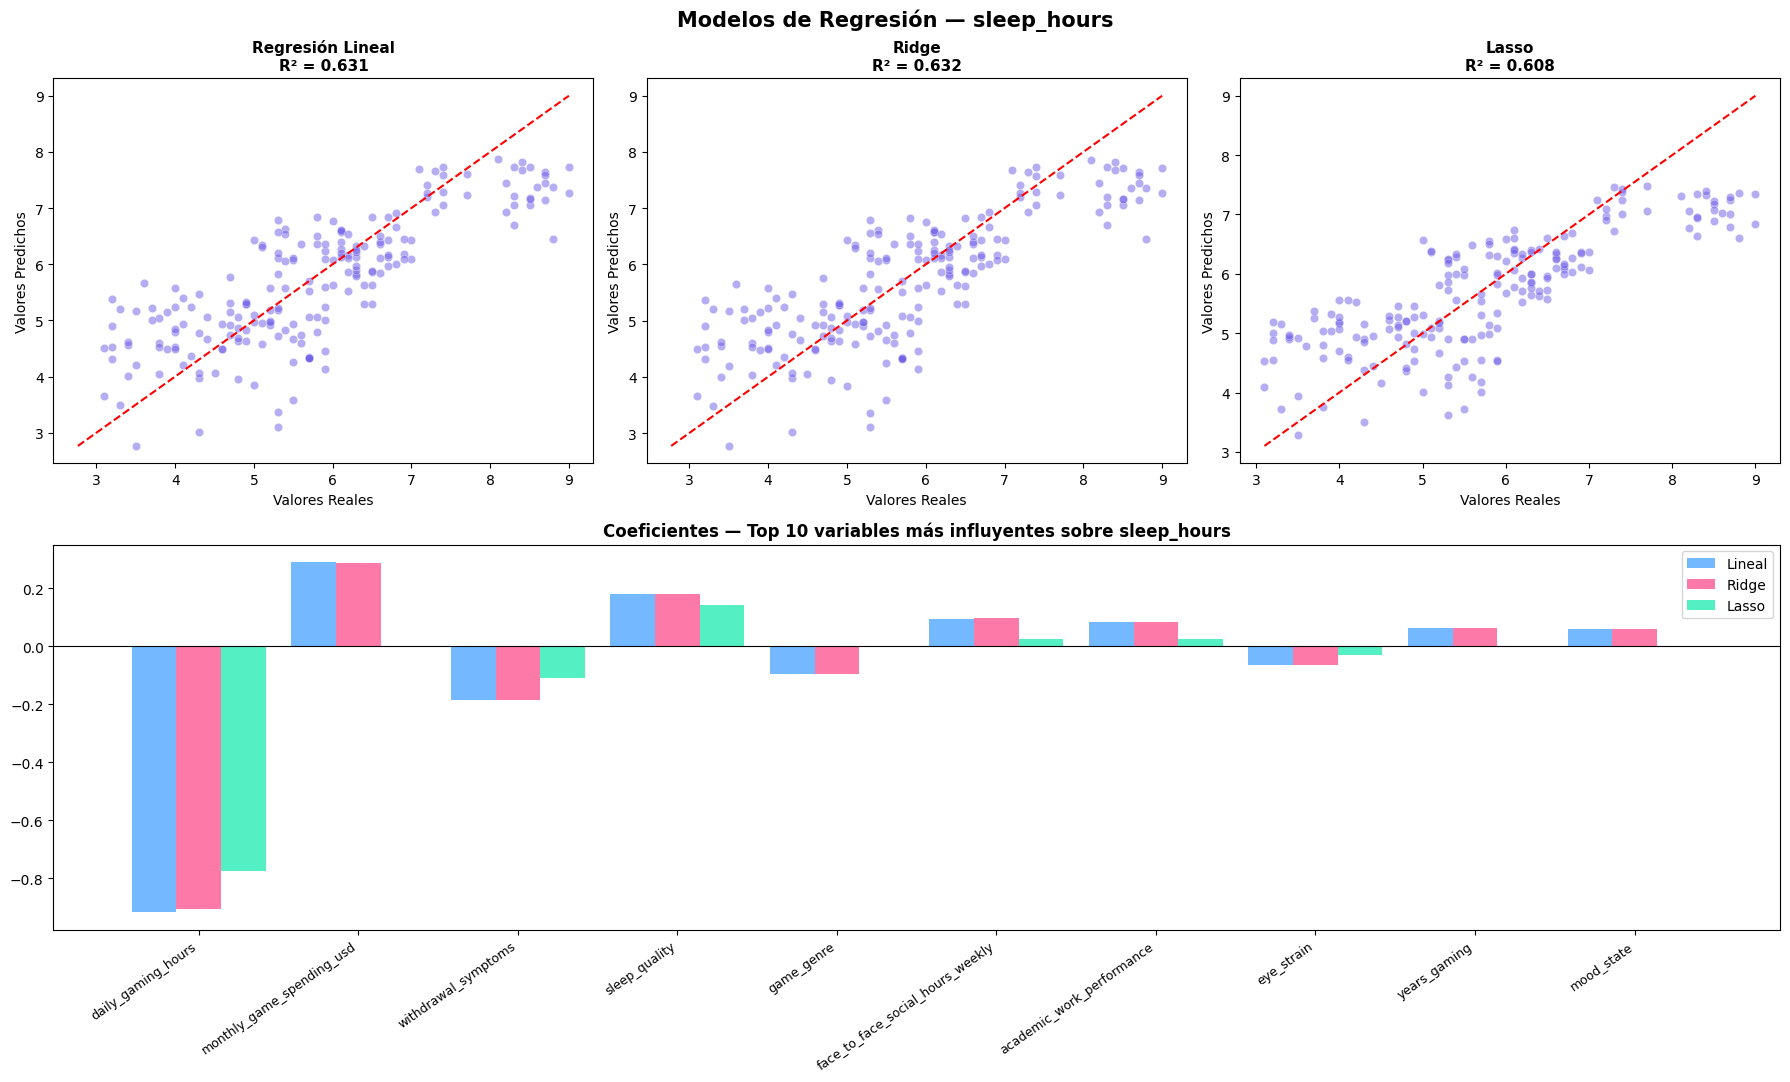

    Gráfico guardado: regresion_completa.png


In [ ]:
print("\n" + "=" * 60)
print(" MODELO DE REGRESIÓN — OBJETIVO: sleep_hours")
print("=" * 60)

TARGET = 'sleep_hours'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

# ── Train / Test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Imputar y escalar ────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

# ── 6.1 Modelos ──────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)

# ── 6.2 Métricas ────────────────────────────────────────────
def metricas(nombre, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n  🔹 {nombre}")
    print(f"     RMSE : {rmse:.4f}")
    print(f"     MAE  : {mae:.4f}")
    print(f"     R²   : {r2:.4f}")
    return rmse, mae, r2

print("\n── Comparativa de Modelos ──────────────────────────────")
rmse_lr,    mae_lr,    r2_lr    = metricas("Regresión Lineal Múltiple", y_test, y_pred_lr)
rmse_ridge, mae_ridge, r2_ridge = metricas("Ridge",                     y_test, y_pred_ridge)
rmse_lasso, mae_lasso, r2_lasso = metricas("Lasso",                     y_test, y_pred_lasso)

# ── 6.3 Importancia de variables (coeficientes) ──────────────
coef_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Coef_LR'   : lr.coef_,
    'Coef_Ridge': ridge.coef_,
    'Coef_Lasso': lasso.coef_,
}).sort_values('Coef_LR', key=abs, ascending=False)

print("\n── Top 10 variables más influyentes (por |coef| LR) ───")
print(coef_df.head(10).to_string(index=False))

# ── 6.4 Layout: fila 1 → Real vs Predicho | fila 2 → Coefs ──
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Modelos de Regresión — sleep_hours", fontsize=15, fontweight='bold')

# Fila 1: 3 scatter plots (Real vs Predicho)
modelos = [
    ("Regresión Lineal", y_pred_lr,    r2_lr),
    ("Ridge",            y_pred_ridge, r2_ridge),
    ("Lasso",            y_pred_lasso, r2_lasso),
]
for i, (nombre, y_pred, r2) in enumerate(modelos):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.scatter(y_test, y_pred, alpha=0.5, color="#6c5ce7", edgecolors='white', linewidth=0.4)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    ax.set_title(f"{nombre}\nR² = {r2:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Valores Reales")
    ax.set_ylabel("Valores Predichos")

# Fila 2: Coeficientes (ocupa las 3 columnas)
ax2 = fig.add_subplot(2, 1, 2)
top10 = coef_df.head(10)
x = np.arange(len(top10))
width = 0.28
ax2.bar(x - width, top10['Coef_LR'],    width, label='Lineal', color='#74b9ff')
ax2.bar(x,         top10['Coef_Ridge'], width, label='Ridge',  color='#fd79a8')
ax2.bar(x + width, top10['Coef_Lasso'], width, label='Lasso',  color='#55efc4')
ax2.set_xticks(x)
ax2.set_xticklabels(top10['Feature'], rotation=35, ha='right', fontsize=9)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title("Coeficientes — Top 10 variables más influyentes sobre sleep_hours",
              fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig("regresion_completa.png", bbox_inches='tight', dpi=150)
plt.show()
print("    Gráfico guardado: regresion_completa.png")

---
## 7. ANÁLISIS EXPLORATORIO ADICIONAL (EDA)
---


 ANÁLISIS EXPLORATORIO — EDA


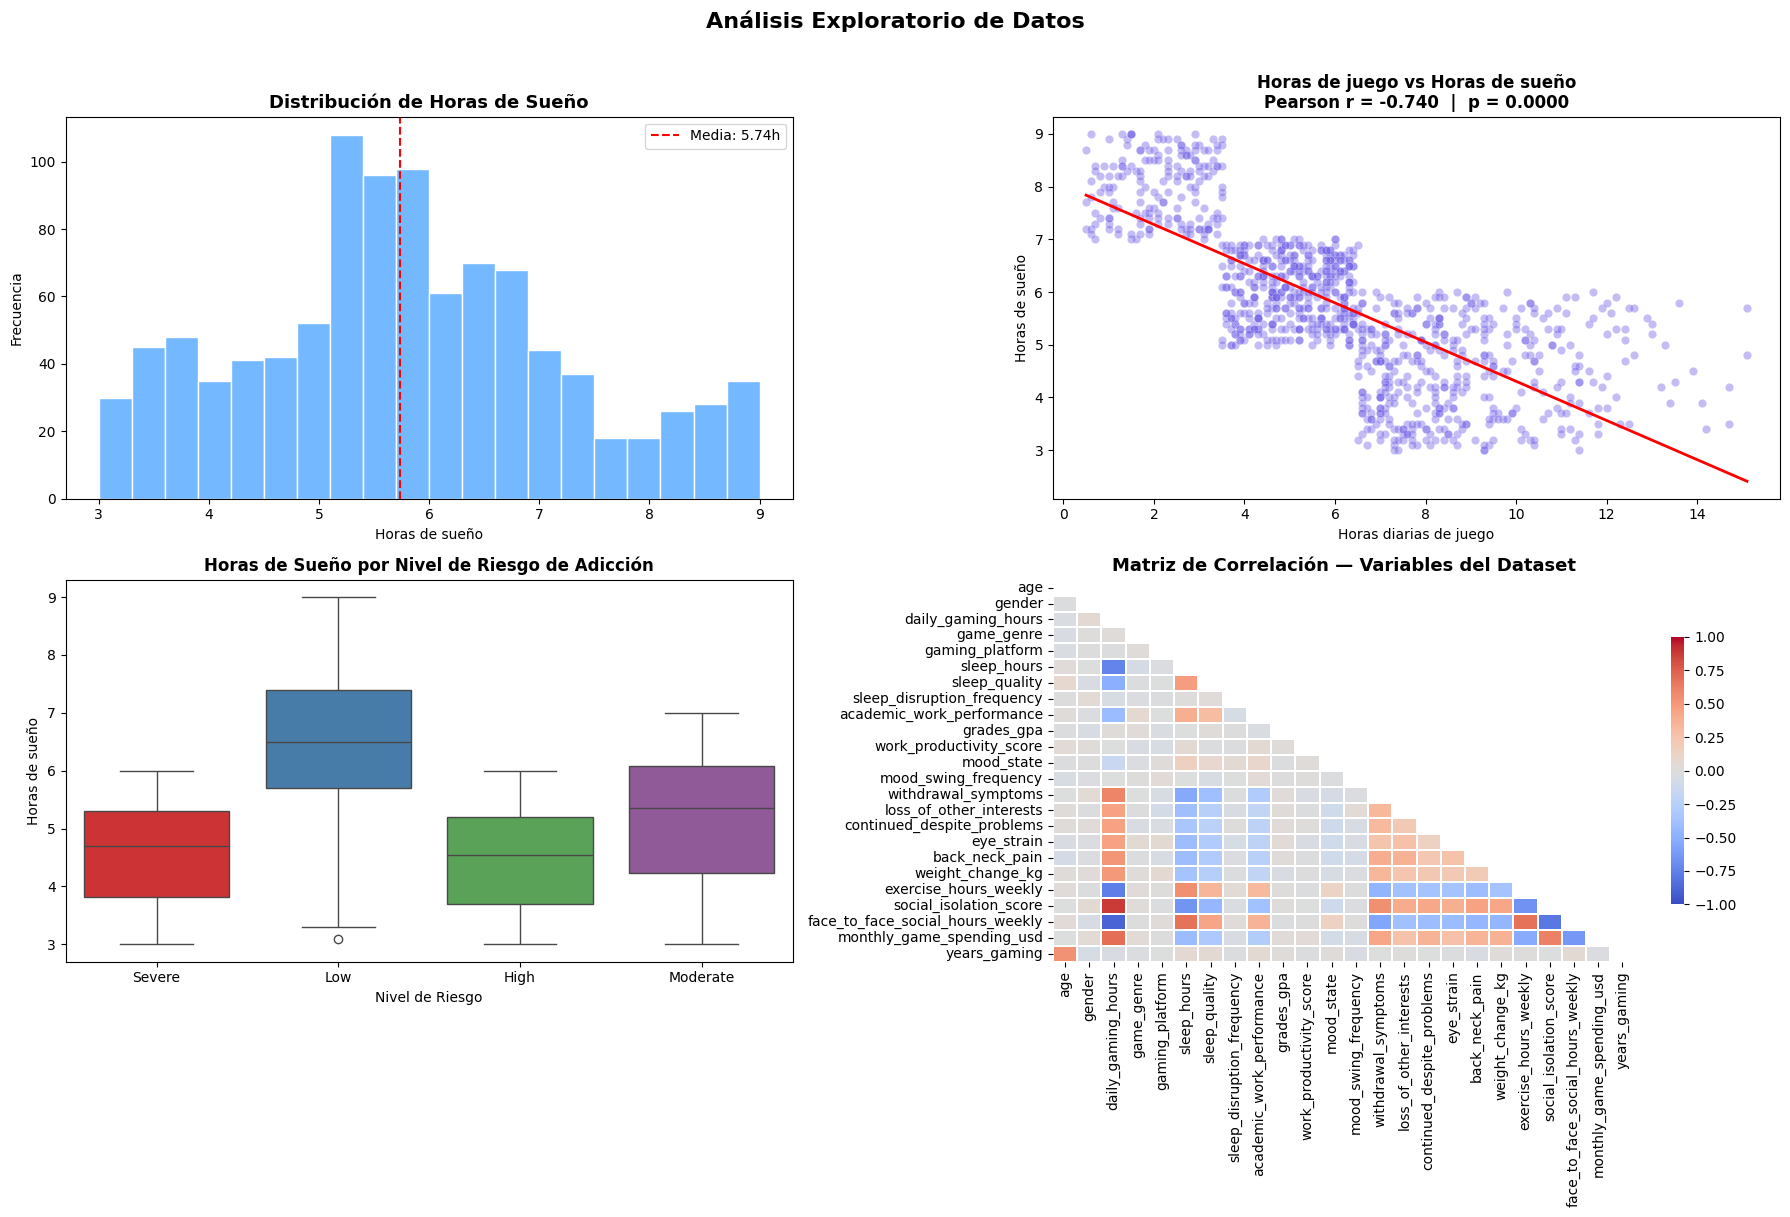

In [ ]:
print("\n" + "=" * 60)
print(" ANÁLISIS EXPLORATORIO — EDA")
print("=" * 60)

# ── Layout: 2 filas × 2 columnas ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Análisis Exploratorio de Datos", fontsize=16, fontweight='bold', y=1.01)

# ── 7.1 Distribución de horas de sueño ──────────────────────
ax = axes[0, 0]
ax.hist(df['sleep_hours'], bins=20, color='#74b9ff', edgecolor='white')
ax.axvline(df['sleep_hours'].mean(), color='red', linestyle='--',
           label=f"Media: {df['sleep_hours'].mean():.2f}h")
ax.set_title("Distribución de Horas de Sueño", fontsize=13, fontweight='bold')
ax.set_xlabel("Horas de sueño")
ax.set_ylabel("Frecuencia")
ax.legend()

# ── 7.2 Correlación horas de juego vs horas de sueño ────────
ax = axes[0, 1]
ax.scatter(df['daily_gaming_hours'], df['sleep_hours'],
           alpha=0.4, color='#6c5ce7', edgecolors='white', linewidth=0.3)
m, b = np.polyfit(df['daily_gaming_hours'], df['sleep_hours'], 1)
xr = np.linspace(df['daily_gaming_hours'].min(), df['daily_gaming_hours'].max(), 100)
ax.plot(xr, m*xr + b, color='red', linewidth=2)
r, p = stats.pearsonr(df['daily_gaming_hours'], df['sleep_hours'])
ax.set_title(f"Horas de juego vs Horas de sueño\nPearson r = {r:.3f}  |  p = {p:.4f}",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Horas diarias de juego")
ax.set_ylabel("Horas de sueño")

# ── 7.3 Sueño por nivel de riesgo de adicción ────────────────
ax = axes[1, 0]
sns.boxplot(data=df, x='gaming_addiction_risk_level', y='sleep_hours',
            hue='gaming_addiction_risk_level', legend=False,
            palette="Set1", ax=ax)
ax.set_title("Horas de Sueño por Nivel de Riesgo de Adicción",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Nivel de Riesgo")
ax.set_ylabel("Horas de sueño")

# ── 7.4 Matriz de correlación ────────────────────────────────
ax = axes[1, 1]
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.7})
ax.set_title("Matriz de Correlación — Variables del Dataset",
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("eda_completo.png", bbox_inches='tight', dpi=150)
plt.show()


# ***Machine Learning***

---

# ***Aplicación de Modelos de Aprendizaje Supervisado***
---

In [ ]:
!pip install tensorflow

---
## 1. VERIFICACIÓN DE LIMPIEZA Y PREPARACIÓN
---

In [ ]:
print("\n" + "=" * 60)
print("  SEGUNDA PRE-ENTREGA - PREPARACIÓN DE DATOS")
print("=" * 60)

# El dataset ya fue limpiado y preprocesado en la sección 5
# Verificamos que no haya valores nulos
print("\n  Verificación de valores nulos:")
print(df_model.isnull().sum().sum(), "valores nulos en total")

# Variable objetivo para clasificación
TARGET_CLASS = 'gaming_addiction_risk_level'

# Verificamos las clases
print(f"\n  Clases en {TARGET_CLASS}:")
print(df[TARGET_CLASS].value_counts())


  SEGUNDA PRE-ENTREGA - PREPARACIÓN DE DATOS

  Verificación de valores nulos:
464 valores nulos en total

  Clases en gaming_addiction_risk_level:
gaming_addiction_risk_level
Low         514
Moderate    190
High        154
Severe      142
Name: count, dtype: int64


---
## 2. PARTICIONADO CON SHUFFLE
---

In [ ]:
print("\n" + "=" * 60)
print("  PARTICIONADO TRAIN/TEST CON SHUFFLE")
print("=" * 60)

# Seleccionar features (excluyendo sleep_hours y la variable objetivo)
FEATURES = [c for c in df_model.columns if c not in [TARGET_CLASS, 'sleep_hours']]

X = df_model[FEATURES]
y = df[TARGET_CLASS]

# Label Encoding para la variable objetivo
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"\n  Clases codificadas: {dict(zip(le_target.classes_, range(len(le_target.classes_))))}")
print(f"  Features: {X.shape[1]} variables")
print(f"  Muestras: {X.shape[0]}")

# Train/test split con shuffle
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, shuffle=True
)
print(f"\n  Train: {X_train.shape[0]} muestras")
print(f"  Test:  {X_test.shape[0]} muestras")

# Escalar los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


  PARTICIONADO TRAIN/TEST CON SHUFFLE

  Clases codificadas: {'High': 0, 'Low': 1, 'Moderate': 2, 'Severe': 3}
  Features: 23 variables
  Muestras: 1000

  Train: 800 muestras
  Test:  200 muestras


---
## 2.1 Verificando NaN después del escalado
---

In [ ]:
# Verificar y corregir NaN después del escalado
from sklearn.impute import SimpleImputer

print("\n  Verificando NaN después del escalado:")
print(f"    NaN en X_train_sc: {np.isnan(X_train_sc).sum().sum()}")
print(f"    NaN en X_test_sc: {np.isnan(X_test_sc).sum().sum()}")

# Si hay NaN, imputar con la media
if np.isnan(X_train_sc).sum().sum() > 0:
    print("\n  ⚠️ Se encontraron NaN. Imputando con la media...")
    imputer_nan = SimpleImputer(strategy='mean')
    X_train_sc = imputer_nan.fit_transform(X_train_sc)
    X_test_sc = imputer_nan.transform(X_test_sc)
    print(f"    NaN después de imputación: {np.isnan(X_train_sc).sum().sum()}")
else:
    print("  ✓ No se encontraron NaN")


  Verificando NaN después del escalado:
    NaN en X_train_sc: 373
    NaN en X_test_sc: 91

  ⚠️ Se encontraron NaN. Imputando con la media...
    NaN después de imputación: 0


---
## 3.1 DECISION TREE CON TUNING DE max_depth
---

In [ ]:
print("\n" + "=" * 60)
print("  3.1 DECISION TREE CON TUNING DE max_depth")
print("=" * 60)

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
dt = DecisionTreeClassifier(random_state=42)
dt_params = {'max_depth': [3, 5, 10, 15, 20, None]}
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train_sc, y_train)

print(f"  Mejor max_depth: {dt_grid.best_params_['max_depth']}")
print(f"  Accuracy CV: {dt_grid.best_score_:.4f}")

# Evaluación en test
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_sc)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"  Accuracy Test: {acc_dt:.4f}")


  3.1 DECISION TREE CON TUNING DE max_depth
  Mejor max_depth: 5
  Accuracy CV: 0.9812
  Accuracy Test: 0.9750


---
## 3.2 RANDOM FOREST CON TUNING
---

In [ ]:
print("\n" + "=" * 60)
print("  3.2 RANDOM FOREST CON TUNING")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None]
}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_sc, y_train)

print(f"  Mejores parámetros: {rf_grid.best_params_}")
print(f"  Accuracy CV: {rf_grid.best_score_:.4f}")

# Evaluación en test
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_sc)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"  Accuracy Test: {acc_rf:.4f}")


  3.2 RANDOM FOREST CON TUNING
  Mejores parámetros: {'max_depth': 10, 'n_estimators': 200}
  Accuracy CV: 0.9587
  Accuracy Test: 0.9800


---
## 3.3 SVM CON DIFERENTES KERNELS
---

In [ ]:
print("\n" + "=" * 60)
print("  3.3 SVM CON DIFERENTES KERNELS")
print("=" * 60)

from sklearn.svm import SVC

svm_results = {}
svm_kernels = ['linear', 'poly', 'rbf']

for kernel in svm_kernels:
    print(f"\n  --- Kernel: {kernel} ---")

    if kernel == 'rbf':
        # Para RBF, probamos diferentes gamma
        for gamma in [0.01, 0.1, 1, 10]:
            svm = SVC(kernel=kernel, gamma=gamma, random_state=42)
            svm.fit(X_train_sc, y_train)
            acc = accuracy_score(y_test, svm.predict(X_test_sc))
            print(f"    gamma={gamma:.2f}: Accuracy Test = {acc:.4f}")
            svm_results[f'SVM_{kernel}_gamma={gamma}'] = acc
    elif kernel == 'poly':
        # Para poly, probamos diferentes grados
        for degree in [2, 3, 4]:
            svm = SVC(kernel=kernel, degree=degree, random_state=42)
            svm.fit(X_train_sc, y_train)
            acc = accuracy_score(y_test, svm.predict(X_test_sc))
            print(f"    degree={degree}: Accuracy Test = {acc:.4f}")
            svm_results[f'SVM_{kernel}_degree={degree}'] = acc
    else:
        svm = SVC(kernel=kernel, random_state=42)
        svm.fit(X_train_sc, y_train)
        acc = accuracy_score(y_test, svm.predict(X_test_sc))
        print(f"    Accuracy Test = {acc:.4f}")
        svm_results[f'SVM_{kernel}'] = acc

# Mejor SVM
best_svm_name = max(svm_results, key=svm_results.get)
print(f"\n  Mejor SVM: {best_svm_name} (Accuracy: {svm_results[best_svm_name]:.4f})")


  3.3 SVM CON DIFERENTES KERNELS

  --- Kernel: linear ---
    Accuracy Test = 0.9800

  --- Kernel: poly ---
    degree=2: Accuracy Test = 0.9650
    degree=3: Accuracy Test = 0.9350
    degree=4: Accuracy Test = 0.7000

  --- Kernel: rbf ---
    gamma=0.01: Accuracy Test = 0.9700
    gamma=0.10: Accuracy Test = 0.9650
    gamma=1.00: Accuracy Test = 0.4950
    gamma=10.00: Accuracy Test = 0.4950

  Mejor SVM: SVM_linear (Accuracy: 0.9800)


In [ ]:
def show_curve_classification(est, X, y, title="Modelo"):
    from sklearn.model_selection import cross_val_score, KFold
    import numpy as np
    import matplotlib.pyplot as plt

    means, stds = [], []
    nfolds_range = range(2, 11)
    for nfolds in nfolds_range:
        kf = KFold(n_splits=nfolds, shuffle=True, random_state=42)

        scores = cross_val_score(
            est, X, y,
            cv=kf,
            scoring='accuracy'
        )

        means.append(np.mean(scores))
        stds.append(np.std(scores))

    means = np.array(means)
    stds = np.array(stds)

    plt.figure(figsize=(8,5))
    plt.plot(nfolds_range, means, color="black", label="Accuracy promedio")
    plt.fill_between(nfolds_range, means-stds, means+stds,
                     color="blue", alpha=0.3, label="± std")

    plt.xlabel("Número de folds")
    plt.ylabel("Accuracy")
    plt.title(f"Estabilidad del modelo - {title}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

---
## 4. CROSS VALIDATION CON DIFERENTES K
---

In [ ]:
print("\n" + "=" * 60)
print("  4. CROSS VALIDATION CON DIFERENTES K")
print("=" * 60)

from sklearn.model_selection import KFold, cross_val_score

k_values = [10, 20, 50]
cv_results = {}

for k in k_values:
    print(f"\n  --- K = {k} ---")
    # Usamos Random Forest como modelo de referencia
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)
    scores = cross_val_score(rf_cv, X_train_sc, y_train, cv=KFold(k, shuffle=True, random_state=42), scoring='accuracy')
    cv_results[k] = (np.mean(scores), np.std(scores))
    print(f"    Accuracy CV: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# Mejor K
best_k = max(cv_results, key=lambda k: cv_results[k][0])
print(f"\n  Mejor K: {best_k} (Accuracy: {cv_results[best_k][0]:.4f})")


  4. CROSS VALIDATION CON DIFERENTES K

  --- K = 10 ---
    Accuracy CV: 0.9550 (+/- 0.0179)

  --- K = 20 ---
    Accuracy CV: 0.9563 (+/- 0.0386)

  --- K = 50 ---
    Accuracy CV: 0.9600 (+/- 0.0429)

  Mejor K: 50 (Accuracy: 0.9600)


---
## 5. DEEP LEARNING CON KERAS
---

In [ ]:
print("\n" + "=" * 60)
print("  5. DEEP LEARNING CON KERAS")
print("=" * 60)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

# One-hot encoding para la variable objetivo
y_train_ohe = to_categorical(y_train, num_classes=4)
y_test_ohe = to_categorical(y_test, num_classes=4)
n_features = X_train_sc.shape[1]
n_classes = 4

print(f"  Features de entrada: {n_features}")
print(f"  Número de clases: {n_classes}")


  5. DEEP LEARNING CON KERAS
  Features de entrada: 23
  Número de clases: 4


---
## 5.1 Modelo 1: (64, 128, 128)
---

In [ ]:
print("\n  --- Modelo 1 ---")
epochs_list = [10, 50, 100]

results_m1 = {}
histories_m1 = {}
models_m1 = {}
for ep in epochs_list:

    print(f"\n    Entrenando con epochs={ep}...")

    model1 = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])

    model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model1.fit(
        X_train_sc, y_train_ohe,
        epochs=ep,
        batch_size=32,
        validation_data=(X_test_sc, y_test_ohe),
        verbose=0
    )

    val_acc = history.history['val_accuracy'][-1]

    print(f"    Epochs={ep}: Validation Accuracy = {val_acc:.4f}")

    results_m1[ep] = val_acc
    histories_m1[ep] = history
    models_m1[ep] = model1

best_ep_m1 = max(results_m1, key=results_m1.get)
best_history_m1 = histories_m1[best_ep_m1]
best_model1 = models_m1[best_ep_m1]

print(f"\n  Mejor epochs para Modelo 1: {best_ep_m1} (Acc: {results_m1[best_ep_m1]:.4f})")


  --- Modelo 1 ---

    Entrenando con epochs=10...
    Epochs=10: Validation Accuracy = 0.9550

    Entrenando con epochs=50...
    Epochs=50: Validation Accuracy = 0.9700

    Entrenando con epochs=100...
    Epochs=100: Validation Accuracy = 0.9700

  Mejor epochs para Modelo 1: 50 (Acc: 0.9700)


---
## 5.2 Modelo 2: (64, 64, 128, 128, 256, 256)
---

In [ ]:
print("\n  --- Modelo 2 ---")

results_m2 = {}
histories_m2 = {}
models_m2 = {}
epochs_list = [10, 50, 100]
for ep in epochs_list:

    print(f"\n    Entrenando con epochs={ep}...")

    model2 = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(256, activation='relu'),
        Dense(256, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])

    model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model2.fit(
        X_train_sc, y_train_ohe,
        epochs=ep,
        batch_size=32,
        validation_data=(X_test_sc, y_test_ohe),
        verbose=0
    )

    val_acc = history.history['val_accuracy'][-1]

    print(f"    Epochs={ep}: Validation Accuracy = {val_acc:.4f}")

    results_m2[ep] = val_acc
    histories_m2[ep] = history
    models_m2[ep] = model2

best_ep_m2 = max(results_m2, key=results_m2.get)
best_history_m2 = histories_m2[best_ep_m2]
best_model2 = models_m2[best_ep_m2]

print(f"\n  Mejor epochs para Modelo 2: {best_ep_m2} (Acc: {results_m2[best_ep_m2]:.4f})")


  --- Modelo 2 ---

    Entrenando con epochs=10...
    Epochs=10: Validation Accuracy = 0.9500

    Entrenando con epochs=50...
    Epochs=50: Validation Accuracy = 0.9650

    Entrenando con epochs=100...
    Epochs=100: Validation Accuracy = 0.9650

  Mejor epochs para Modelo 2: 50 (Acc: 0.9650)


---
## 5.3 Modelo 3: (10 x 128 ,40)
---

In [ ]:
print("\n  --- Modelo 3 ---")

results_m3 = {}
histories_m3 = {}
models_m3 = {}
epochs_list = [10, 50, 100]
for ep in epochs_list:

    print(f"\n    Entrenando con epochs={ep}...")

    model3 = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(40, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])

    model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model3.fit(
        X_train_sc, y_train_ohe,
        epochs=ep,
        batch_size=32,
        validation_data=(X_test_sc, y_test_ohe),
        verbose=0
    )

    val_acc = history.history['val_accuracy'][-1]

    print(f"    Epochs={ep}: Validation Accuracy = {val_acc:.4f}")

    results_m3[ep] = val_acc
    histories_m3[ep] = history
    models_m3[ep] = model3

best_ep_m3 = max(results_m3, key=results_m3.get)
best_history_m3 = histories_m3[best_ep_m3]
best_model3 = models_m3[best_ep_m3]

print(f"\n  Mejor epochs para Modelo 3: {best_ep_m3} (Acc: {results_m3[best_ep_m3]:.4f})")


  --- Modelo 3 ---

    Entrenando con epochs=10...
    Epochs=10: Validation Accuracy = 0.9650

    Entrenando con epochs=50...
    Epochs=50: Validation Accuracy = 0.9700

    Entrenando con epochs=100...
    Epochs=100: Validation Accuracy = 0.9600

  Mejor epochs para Modelo 3: 50 (Acc: 0.9700)


---
## 5.4 Modelo 4,5,6: (Regresion)
---

In [ ]:
print("\n" + "=" * 60)
print("  REGRESIÓN DNN ")
print("=" * 60)

from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


# CALLBACK (EVITA SOBREAJUSTE)

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)


# FUNCIONES PARA CREAR MODELOS


def build_model_1():
    model = Sequential([
        Input(shape=(X_train_reg_sc.shape[1],)),
        Dense(64, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_model_2():
    model = Sequential([
        Input(shape=(X_train_reg_sc.shape[1],)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(256, activation='relu'),
        Dense(256, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_model_3():
    model = Sequential([
        Input(shape=(X_train_reg_sc.shape[1],)),
        Dense(128, activation='relu'),
        *[Dense(128, activation='relu') for _ in range(9)],
        Dense(40, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model



# FUNCIÓN GENERAL DE ENTRENAMIENTO


def train_and_select(build_fn, name):
    print(f"\n--- {name} ---")

    best_mae = float('inf')

    for ep in [10, 50, 100]:
        model = build_fn()

        history = model.fit(
            X_train_reg_sc, y_train_reg,
            epochs=ep,
            batch_size=32,
            validation_data=(X_test_reg_sc, y_test_reg),
            callbacks=[early_stop],
            verbose=0
        )

        y_pred = model.predict(X_test_reg_sc, verbose=0)
        mae = mean_absolute_error(y_test_reg, y_pred)
        r2  = r2_score(y_test_reg, y_pred)

        print(f"    Epochs={ep}: MAE={mae:.4f}  R2={r2:.4f}")

        if mae < best_mae:
            best_mae = mae
            best_ep = ep
            best_model = model
            best_pred = y_pred
            best_history = history

    print(f"    Mejor epochs: {best_ep}")

    return best_model, best_pred, best_history, best_ep, best_mae



# ENTRENAR LOS 3 MODELOS


model1_reg, y_pred_m1_reg, best_history_m1_reg, best_ep_m1_reg, mae_m1 = train_and_select(
    build_model_1, "Modelo 1 (64→128→128)"
)

model2_reg, y_pred_m2_reg, best_history_m2_reg, best_ep_m2_reg, mae_m2 = train_and_select(
    build_model_2, "Modelo 2 (64→64→128→128→256→256)"
)

model3_reg, y_pred_m3_reg, best_history_m3_reg, best_ep_m3_reg, mae_m3 = train_and_select(
    build_model_3, "Modelo 3 (128x10→40)"
)



# RESUMEN FINAL


print("\n" + "=" * 60)
print("  RESUMEN REGRESION DNN ")
print("=" * 60)

print(f"  Modelo 1: MAE={mae_m1:.4f}  (epochs={best_ep_m1_reg})")
print(f"  Modelo 2: MAE={mae_m2:.4f}  (epochs={best_ep_m2_reg})")
print(f"  Modelo 3: MAE={mae_m3:.4f}  (epochs={best_ep_m3_reg})")


  REGRESIÓN DNN 

--- Modelo 1 (64→128→128) ---
    Epochs=10: MAE=0.7586  R2=0.5661
    Epochs=50: MAE=1.4914  R2=-0.6148


    Epochs=100: MAE=1.2733  R2=-0.2297
    Mejor epochs: 10

--- Modelo 2 (64→64→128→128→256→256) ---


    Epochs=10: MAE=0.7374  R2=0.5878
    Epochs=50: MAE=1.0318  R2=0.2094
    Epochs=100: MAE=1.0605  R2=0.2288
    Mejor epochs: 10

--- Modelo 3 (128x10→40) ---
    Epochs=10: MAE=0.7409  R2=0.5967
    Epochs=50: MAE=1.0416  R2=0.1801
    Epochs=100: MAE=1.1775  R2=-0.0092
    Mejor epochs: 10

  RESUMEN REGRESION DNN 
  Modelo 1: MAE=0.7586  (epochs=10)
  Modelo 2: MAE=0.7374  (epochs=10)
  Modelo 3: MAE=0.7409  (epochs=10)


---
## 6. GRÁFICAS COMPARATIVAS DE RESULTADOS
---


  6. GRÁFICAS COMPARATIVAS DE RESULTADOS

  6.1 MODELOS DE CLASIFICACIÓN

  --- Decision Tree ---


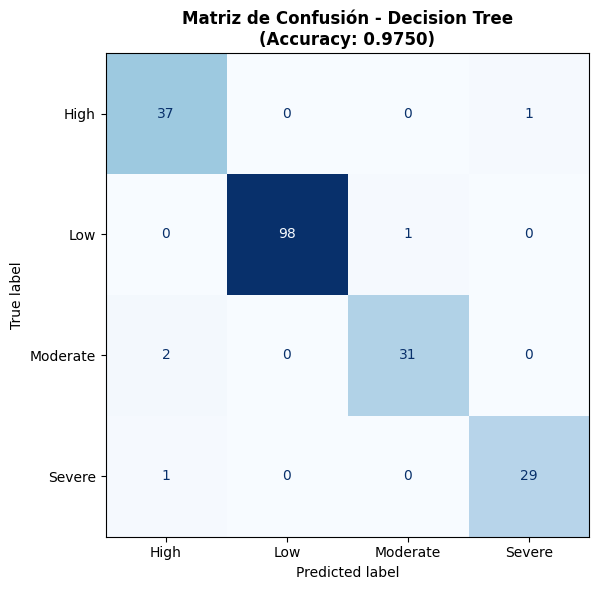


  --- Random Forest ---


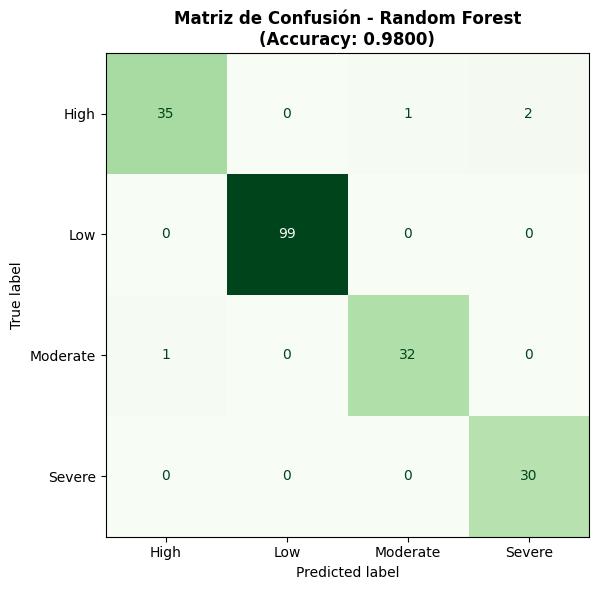


  --- SVM por Kernel ---


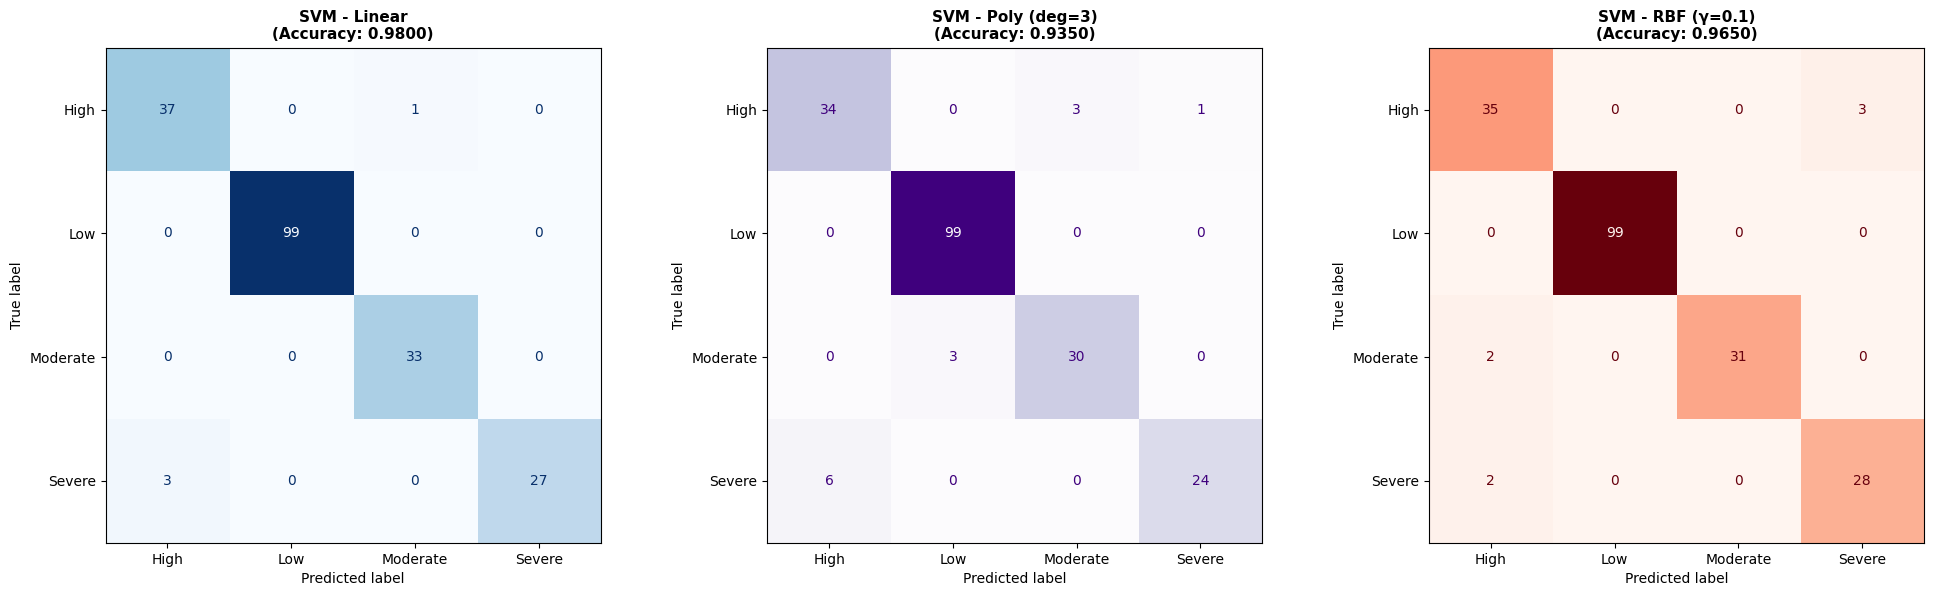


  --- DNN Clasificación ---


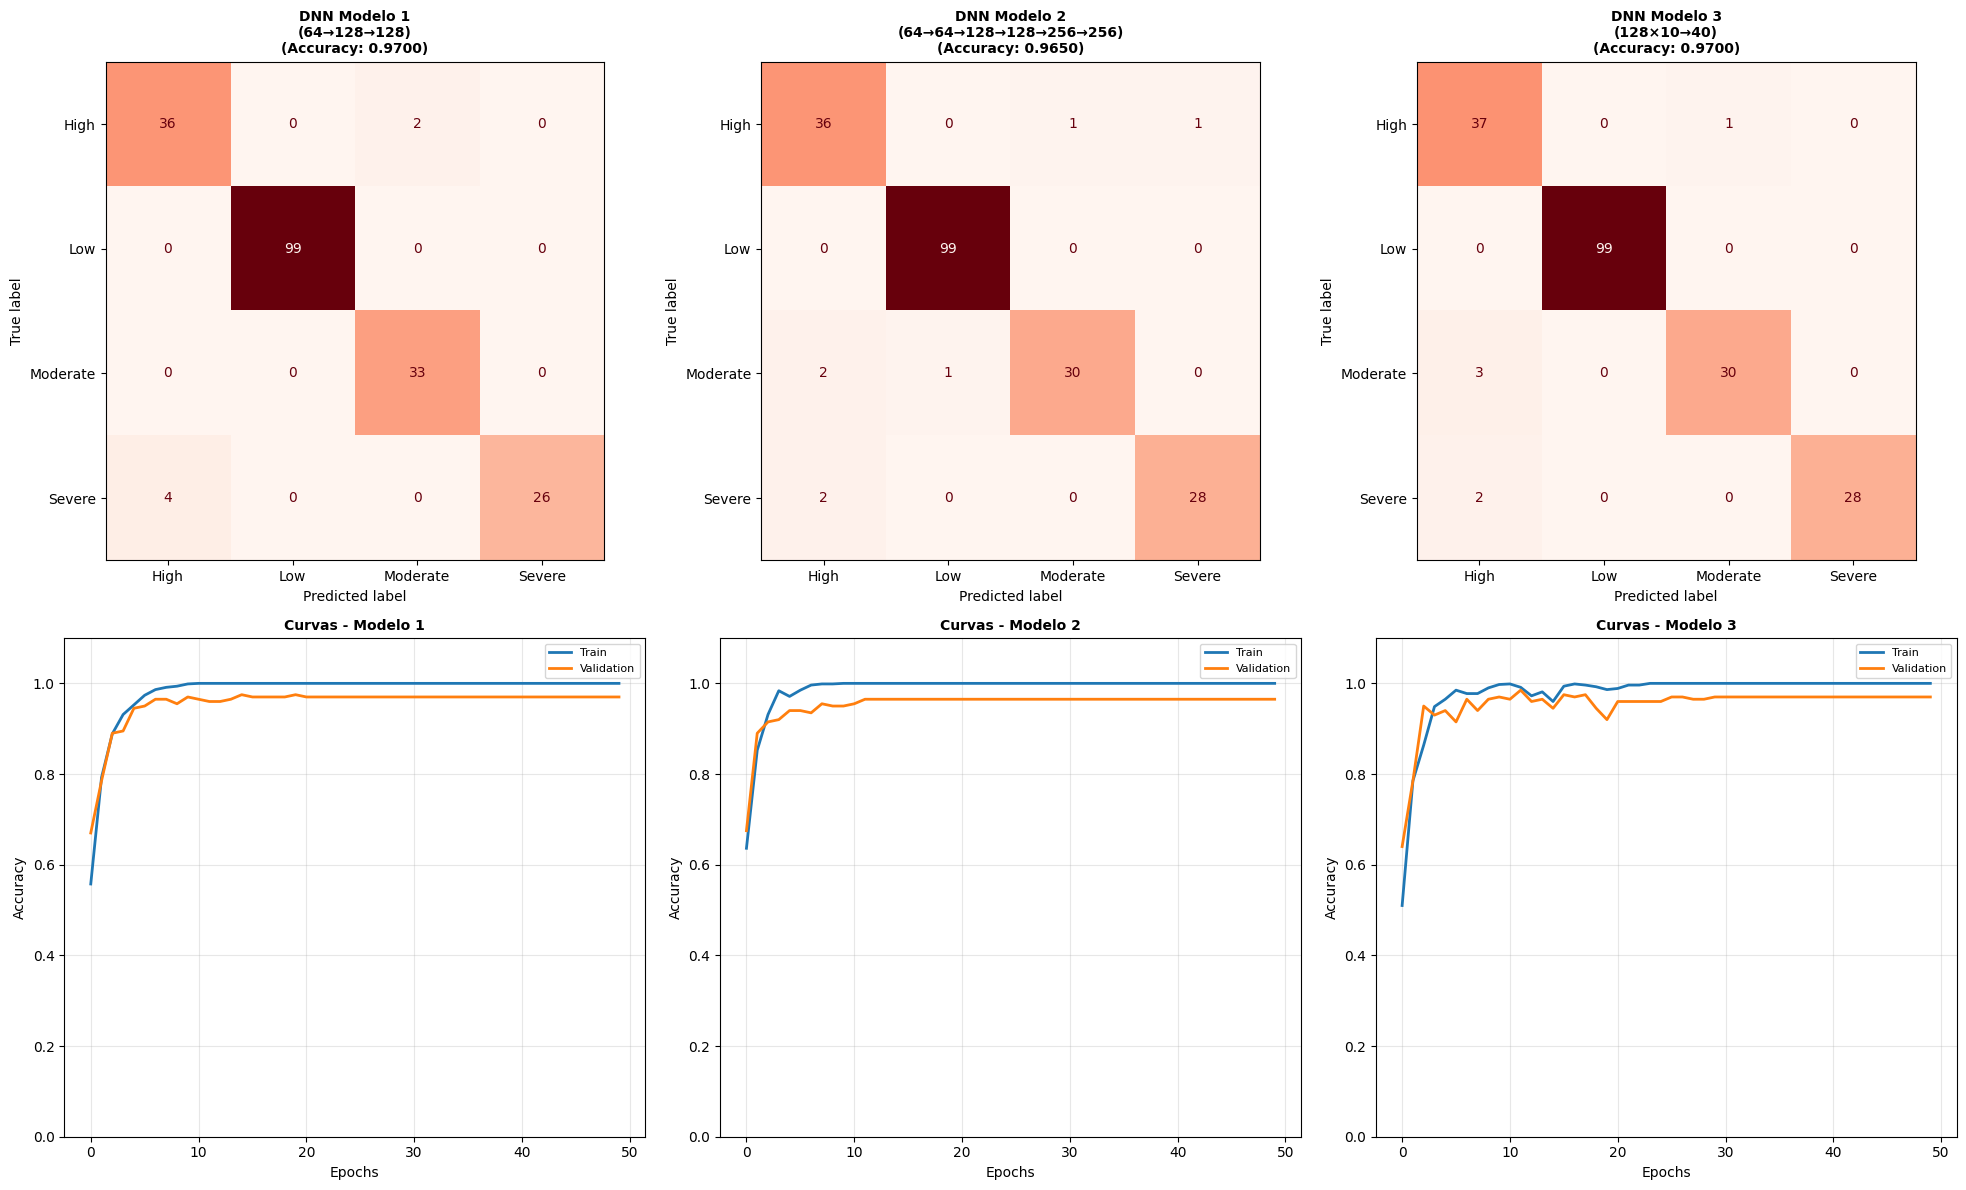


  6.2 MODELOS DE REGRESIÓN (DNN)


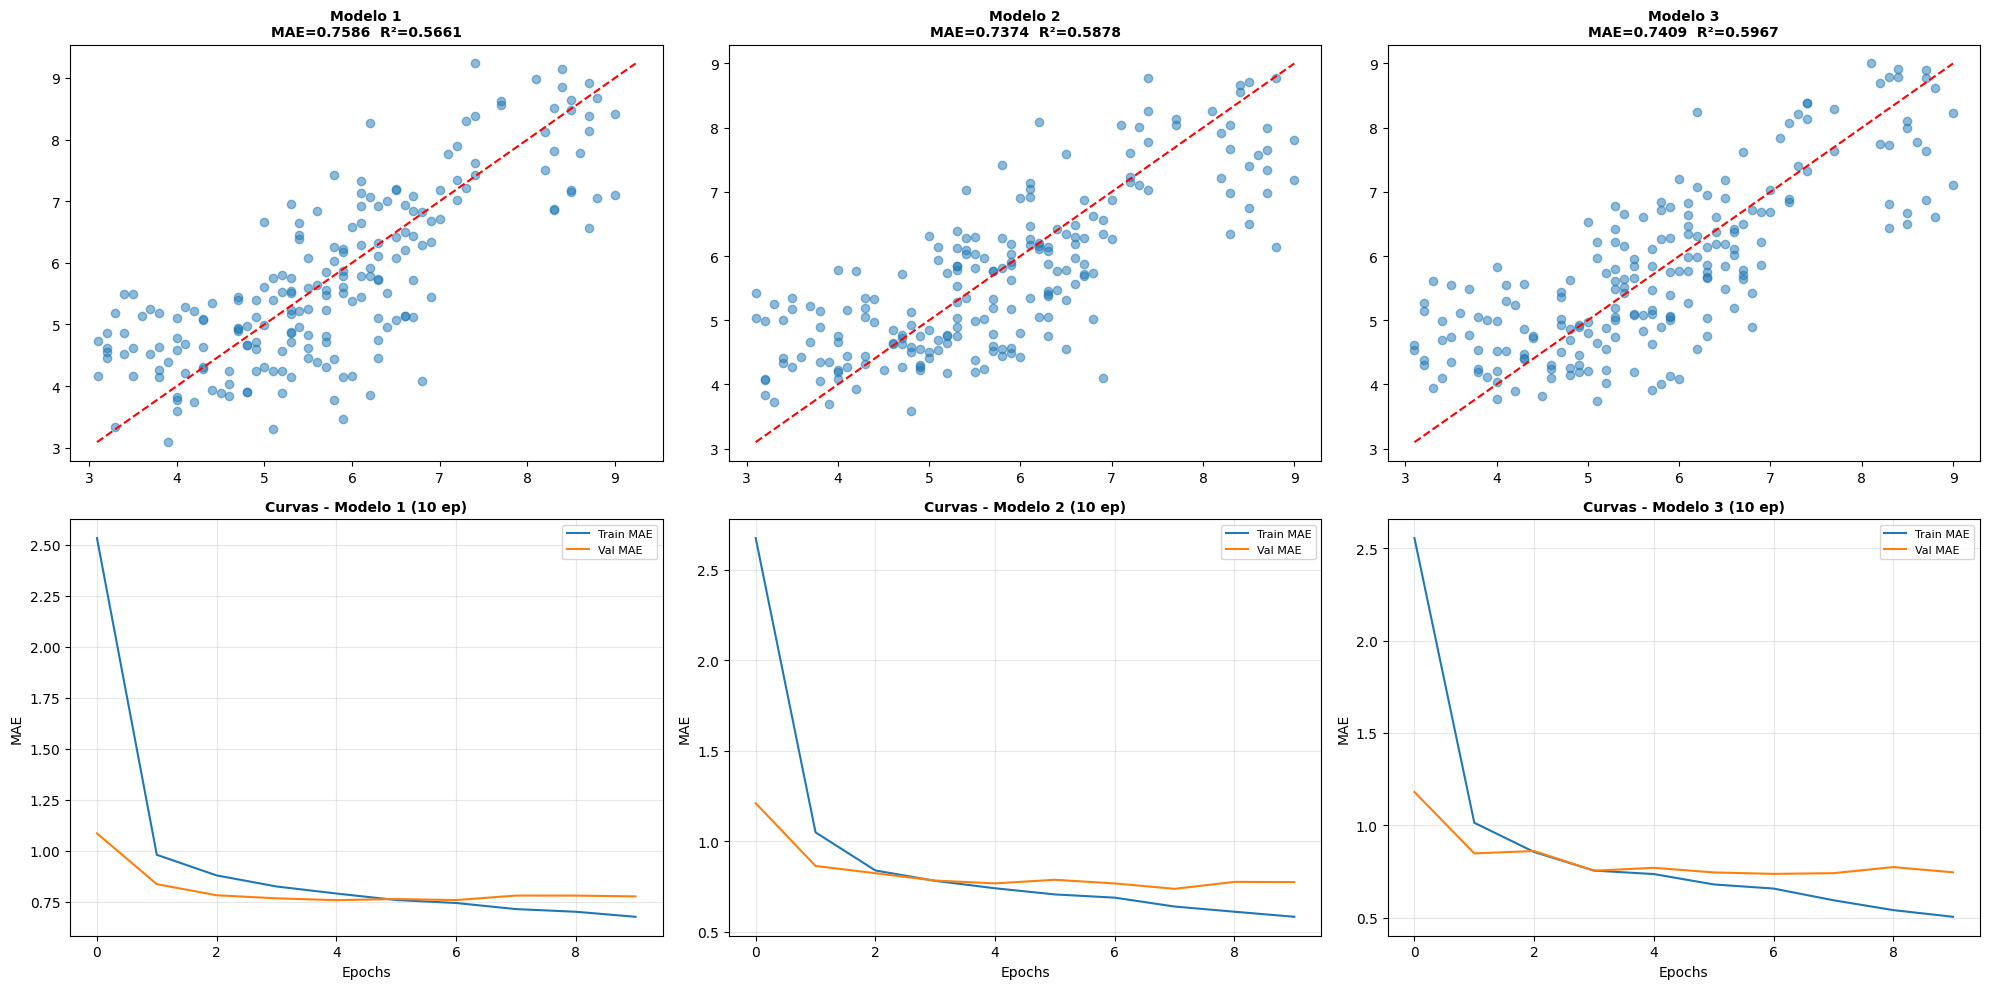


  --- Comparativa Regresión ---


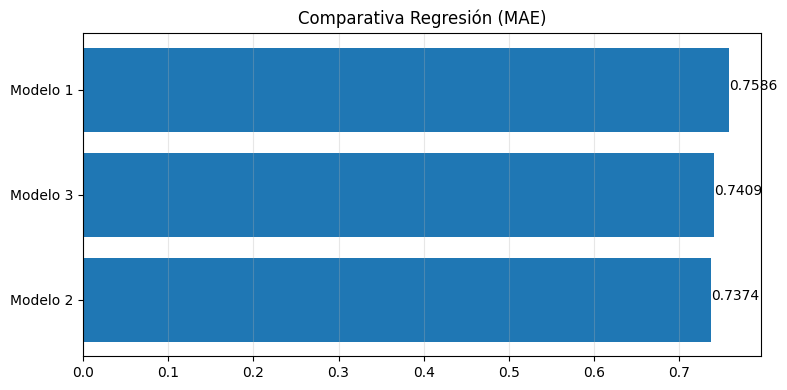


  --- Comparativa Clasificación ---


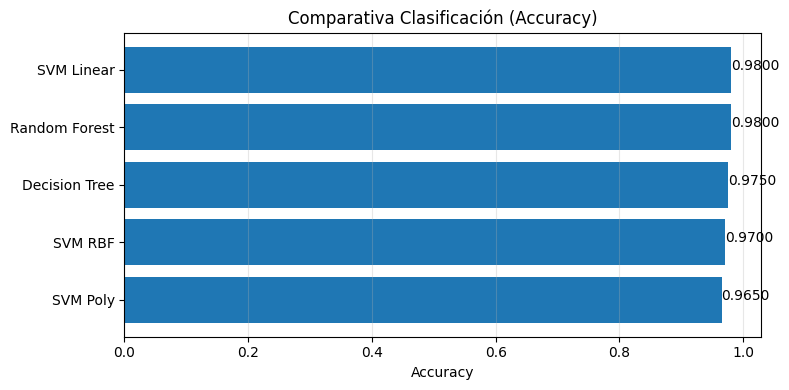

In [ ]:
print("\n" + "=" * 60)
print("  6. GRÁFICAS COMPARATIVAS DE RESULTADOS")
print("=" * 60)


# 6.1 MODELOS DE CLASIFICACIÓN

print("\n" + "=" * 60)
print("  6.1 MODELOS DE CLASIFICACIÓN")
print("=" * 60)

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
import numpy as np


from sklearn.preprocessing import LabelEncoder
le_target_plot = LabelEncoder()
y_original = df['gaming_addiction_risk_level']
le_target_plot.fit(y_original)
class_labels = le_target_plot.classes_

# ------------------ Decision Tree ------------------
print("\n  --- Decision Tree ---")
fig, ax = plt.subplots(figsize=(8, 6))

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=class_labels).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_title(f'Matriz de Confusión - Decision Tree\n(Accuracy: {acc_dt:.4f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ------------------ Random Forest ------------------
print("\n  --- Random Forest ---")
fig, ax = plt.subplots(figsize=(8, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=class_labels).plot(
    ax=ax, cmap='Greens', colorbar=False, values_format='d'
)
ax.set_title(f'Matriz de Confusión - Random Forest\n(Accuracy: {acc_rf:.4f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ------------------ SVM ------------------
print("\n  --- SVM por Kernel ---")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

svm_configs = [
    ('Linear', SVC(kernel='linear', random_state=42), 'Blues'),
    ('Poly (deg=3)', SVC(kernel='poly', degree=3, random_state=42), 'Purples'),
    ('RBF (γ=0.1)', SVC(kernel='rbf', gamma=0.1, random_state=42), 'Reds'),
]

svm_results_local = {}

for i, (name, model, cmap) in enumerate(svm_configs):
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, pred)
    svm_results_local[name] = acc

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
        ax=axes[i], cmap=cmap, colorbar=False, values_format='d'
    )
    axes[i].set_title(f'SVM - {name}\n(Accuracy: {acc:.4f})',
                      fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ------------------ DNN Clasificación ------------------
print("\n  --- DNN Clasificación ---")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()


dnn_models_real = [
    ("DNN Modelo 1\n(64→128→128)", best_model1, best_history_m1),
    ("DNN Modelo 2\n(64→64→128→128→256→256)", best_model2, best_history_m2),
    ("DNN Modelo 3\n(128×10→40)", best_model3, best_history_m3),
]

dnn_class_acc = {}

for idx, (name, model, history) in enumerate(dnn_models_real):

    y_pred_dnn = np.argmax(model.predict(X_test_sc, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred_dnn)
    dnn_class_acc[name.replace('\n', ' ')] = acc

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_dnn)
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
        ax=axes[idx], cmap='Reds', colorbar=False, values_format='d'
    )

    axes[idx].set_title(f'{name}\n(Accuracy: {acc:.4f})',
                        fontsize=10, fontweight='bold')

    # Learning curve
    ax_curve = axes[idx + 3]
    ax_curve.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax_curve.plot(history.history['val_accuracy'], label='Validation', linewidth=2)

    ax_curve.set_title(f'Curvas - Modelo {idx+1}',
                       fontsize=10, fontweight='bold')
    ax_curve.set_xlabel('Epochs')
    ax_curve.set_ylabel('Accuracy')
    ax_curve.set_ylim(0, 1.1)
    ax_curve.legend(fontsize=8)
    ax_curve.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 6.2 REGRESIÓN

print("\n" + "=" * 60)
print("  6.2 MODELOS DE REGRESIÓN (DNN)")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()


reg_models = [
    ("Modelo 1", model1_reg, y_pred_m1_reg, best_history_m1_reg, best_ep_m1_reg),
    ("Modelo 2", model2_reg, y_pred_m2_reg, best_history_m2_reg, best_ep_m2_reg),
    ("Modelo 3", model3_reg, y_pred_m3_reg, best_history_m3_reg, best_ep_m3_reg),
]

reg_results = {}

for idx, (name, model, y_pred, history, best_ep) in enumerate(reg_models):

    mae = mean_absolute_error(y_test_reg, y_pred)
    r2  = r2_score(y_test_reg, y_pred)

    reg_results[name] = mae

    ax = axes[idx]
    ax.scatter(y_test_reg, y_pred, alpha=0.5)

    mn = min(y_test_reg.min(), y_pred.min())
    mx = max(y_test_reg.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--')

    ax.set_title(f'{name}\nMAE={mae:.4f}  R²={r2:.4f}',
                 fontsize=10, fontweight='bold')

    ax2 = axes[idx + 3]

    ax2.plot(history.history['mae'], label='Train MAE')
    ax2.plot(history.history['val_mae'], label='Val MAE')

    ax2.set_title(f'Curvas - {name} ({best_ep} ep)',
                  fontsize=10, fontweight='bold')

    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('MAE')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6.3 COMPARATIVA FINAL

print("\n  --- Comparativa Regresión ---")

reg_results = dict(sorted(reg_results.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(reg_results.keys()), list(reg_results.values()))

for bar, val in zip(bars, reg_results.values()):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.4f}')

ax.set_title('Comparativa Regresión (MAE)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


print("\n  --- Comparativa Clasificación ---")

class_results = {
    "Decision Tree": acc_dt,
    "Random Forest": acc_rf,
    "SVM Linear": svm_results.get("SVM_linear", 0),
    "SVM Poly": max([v for k,v in svm_results.items() if "poly" in k], default=0),
    "SVM RBF": max([v for k,v in svm_results.items() if "rbf" in k], default=0),
}

class_results = dict(sorted(class_results.items(), key=lambda x: x[1]))


fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(class_results.keys()), list(class_results.values()))

for bar, val in zip(bars, class_results.values()):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.4f}')

ax.set_title('Comparativa Clasificación (Accuracy)')
ax.set_xlabel('Accuracy')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## ***Aplicación de Modelos de Aprendizaje no supervisado***
---

### 0) Escalado con MinMaxScaler

In [55]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer

# Reutilizamos df_model ya preprocesado
X_cluster = df_model.drop(columns=['sleep_hours'], errors='ignore').copy()

# Imputar NaN restantes
imputer_c = SimpleImputer(strategy='mean')
X_cluster_imp = imputer_c.fit_transform(X_cluster)

# MinMaxScaler
scaler_mm = MinMaxScaler()
X_scaled = scaler_mm.fit_transform(X_cluster_imp)

print(f'Escalado MinMaxScaler aplicado: {X_scaled.shape[0]} muestras x {X_scaled.shape[1]} features')


Escalado MinMaxScaler aplicado: 1000 muestras x 23 features


### 1) Reducción de Dimensionalidad — PCA (num. cols del dataset → 2 componentes)

In [56]:
# PCA: reducir desde el numero de columnas del dataset hasta 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print('PCA completado:')
print(f'  Componente 1 : {varianza[0]*100:.2f}% de varianza explicada')
print(f'  Componente 2 : {varianza[1]*100:.2f}% de varianza explicada')
print(f'  Total        : {sum(varianza)*100:.2f}%')
print(f'  Shape resultante: {X_pca.shape}')


PCA completado:
  Componente 1 : 26.08% de varianza explicada
  Componente 2 : 8.49% de varianza explicada
  Total        : 34.57%
  Shape resultante: (1000, 2)


### 2) KMeans — n_clusters = número de clases del dataset

El dataset `gaming_addiction_risk_level` tiene **4 clases**: Low, Moderate, High, Severe.

In [57]:
# n_clusters = numero de clases del dataset
N_CLUSTERS = df['gaming_addiction_risk_level'].nunique()
print(f'Clases en el dataset: {sorted(df["gaming_addiction_risk_level"].unique())}')
print(f'n_clusters = {N_CLUSTERS}')

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_pca)

print(f'KMeans aplicado correctamente.')
print(f'  Inercia (WCSS): {kmeans.inertia_:.2f}')


Clases en el dataset: ['High', 'Low', 'Moderate', 'Severe']
n_clusters = 4
KMeans aplicado correctamente.
  Inercia (WCSS): 104.48


### 3) DBSCAN — búsqueda de eps y min_samples adecuados



In [63]:
# Aplicar DBSCAN con los parametros encontrados
EPS = 0.067
MIN_SAMPLES = 3

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = (labels_dbscan == -1).sum()

print('DBSCAN aplicado:')
print(f'  eps         = {EPS:.4f}')
print(f'  min_samples = {MIN_SAMPLES}')
print(f'  Clusters encontrados : {n_clusters_db}')
print(f'  Puntos ruido (noise) : {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)')


DBSCAN aplicado:
  eps         = 0.0670
  min_samples = 3
  Clusters encontrados : 21
  Puntos ruido (noise) : 62 (6.2%)


### 4) Gráficas de Resultados — Original | KMeans | DBSCAN

/tmp/ipykernel_2483/2634119405.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_real   = plt.cm.get_cmap('tab10', len(class_names))
/tmp/ipykernel_2483/2634119405.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_kmeans = plt.cm.get_cmap('Set1',  N_CLUSTERS)
/tmp/ipykernel_2483/2634119405.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db     = plt.cm.get_cmap('tab20', len(unique_db))


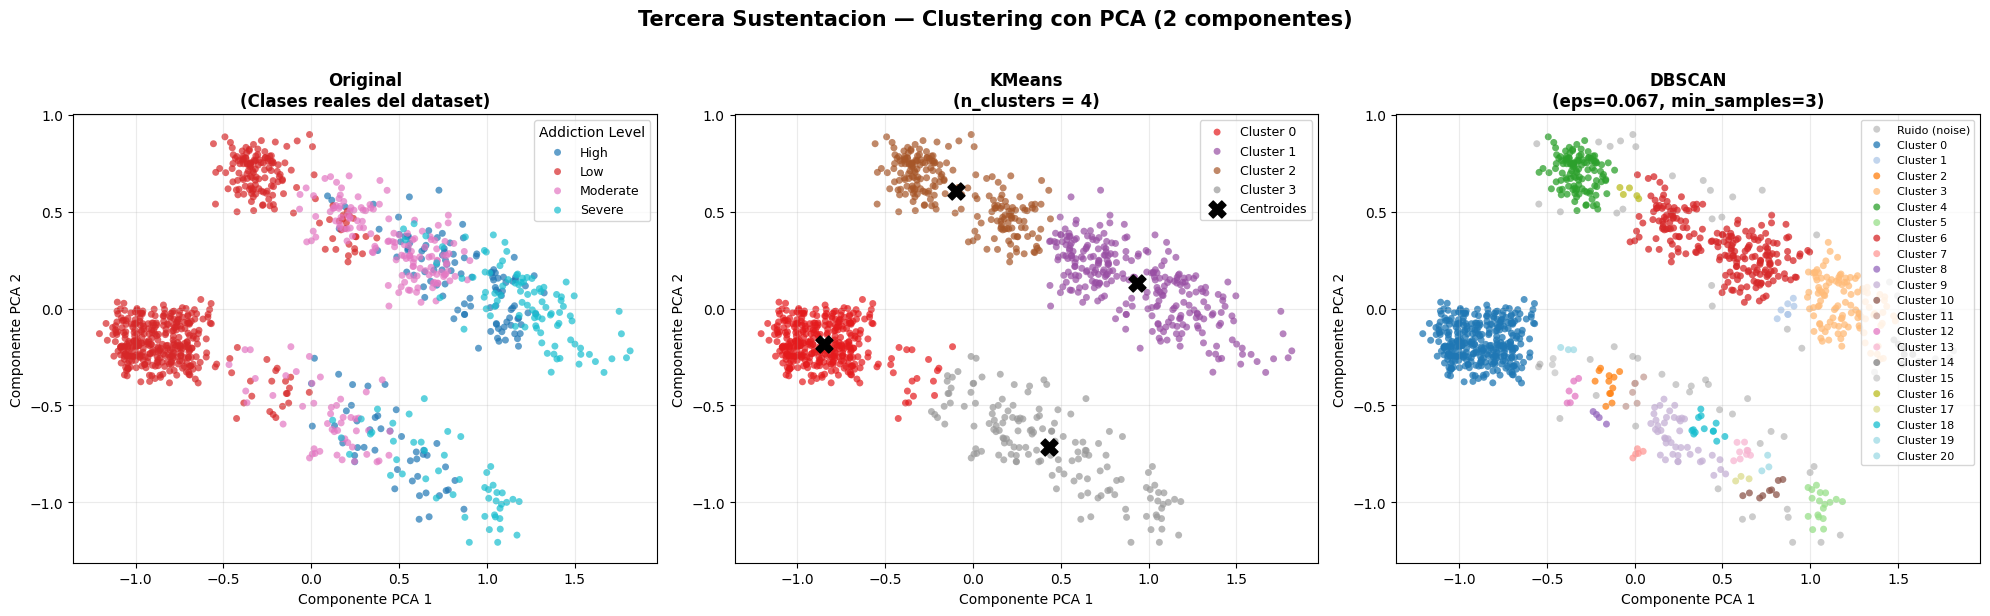

Grafica guardada: clustering_resultados.png


In [64]:
from sklearn.preprocessing import LabelEncoder

# Etiquetas reales para el grafico Original
le_orig = LabelEncoder()
labels_real = le_orig.fit_transform(df['gaming_addiction_risk_level'])
class_names = le_orig.classes_

cmap_real   = plt.cm.get_cmap('tab10', len(class_names))
cmap_kmeans = plt.cm.get_cmap('Set1',  N_CLUSTERS)
unique_db   = sorted(set(labels_dbscan))
cmap_db     = plt.cm.get_cmap('tab20', len(unique_db))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Tercera Sustentacion — Clustering con PCA (2 componentes)',
             fontsize=15, fontweight='bold', y=1.02)

# --- Original (clases reales) ---
ax = axes[0]
for i, cls in enumerate(class_names):
    mask = labels_real == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cmap_real(i)],
               label=cls, s=25, alpha=0.7, edgecolors='none')
ax.set_title('Original\n(Clases reales del dataset)', fontsize=12, fontweight='bold')
ax.set_xlabel('Componente PCA 1'); ax.set_ylabel('Componente PCA 2')
ax.legend(title='Addiction Level', fontsize=9, title_fontsize=10,
          loc='best', framealpha=0.8)
ax.grid(True, alpha=0.25)

# --- KMeans ---
ax = axes[1]
centers = kmeans.cluster_centers_
for c in range(N_CLUSTERS):
    mask = labels_kmeans == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cmap_kmeans(c)],
               label=f'Cluster {c}', s=25, alpha=0.7, edgecolors='none')
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X',
           s=150, zorder=5, label='Centroides')
ax.set_title(f'KMeans\n(n_clusters = {N_CLUSTERS})', fontsize=12, fontweight='bold')
ax.set_xlabel('Componente PCA 1'); ax.set_ylabel('Componente PCA 2')
ax.legend(fontsize=9, loc='best', framealpha=0.8)
ax.grid(True, alpha=0.25)

# --- DBSCAN ---
ax = axes[2]
for i, lbl in enumerate(unique_db):
    mask = labels_dbscan == lbl
    color = 'gray' if lbl == -1 else cmap_db(i)
    name  = 'Ruido (noise)' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=name,
               s=25, alpha=0.4 if lbl == -1 else 0.75, edgecolors='none')
ax.set_title(f'DBSCAN\n(eps={EPS:.3f}, min_samples={MIN_SAMPLES})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Componente PCA 1'); ax.set_ylabel('Componente PCA 2')
ax.legend(fontsize=8, loc='best', framealpha=0.8)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('clustering_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: clustering_resultados.png')
